In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

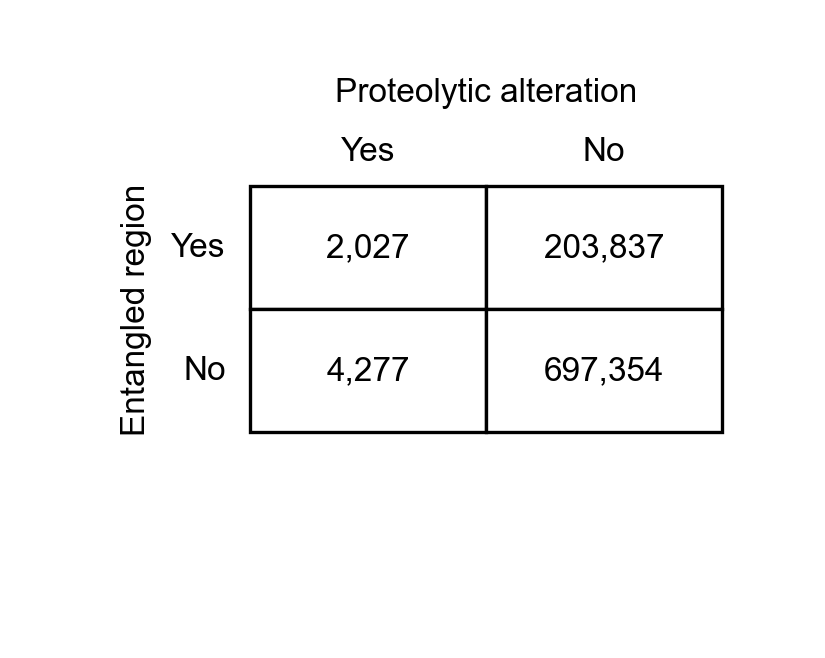

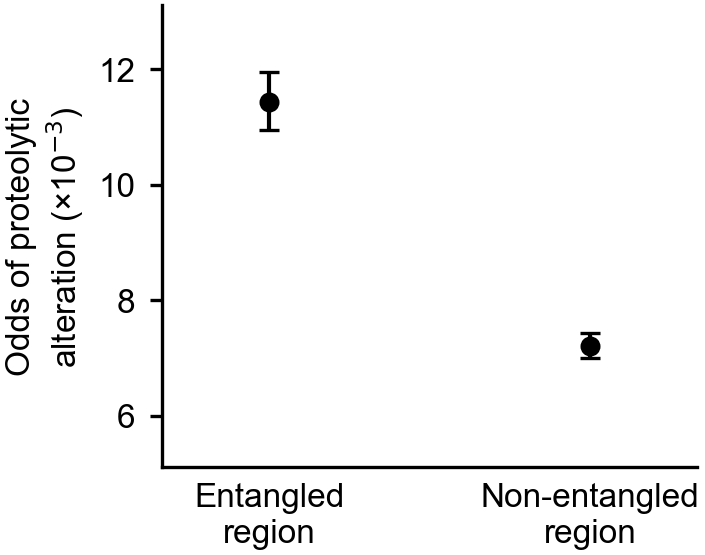

In [4]:
# ----------------------------
# 1) One shared Nature-like style
# ----------------------------
BASE_FONTSIZE = 8

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": BASE_FONTSIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "axes.labelsize": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.linewidth": 0.8,
    "axes.spines.right": False,
    "axes.spines.top": False,

    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 0,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    "legend.fontsize": BASE_FONTSIZE,
    "legend.frameon": False,

    "figure.dpi": 300,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


# ----------------------------
# 2) Panel A (table) using SAME sizing
# ----------------------------
def draw_panel_b(
    counts=((2027, 203837),
            (4277,  697354)),
    row_labels=("Yes", "No"),
    col_labels=("Yes", "No"),
    title_top="Proteolytic alteration",
    title_left="Entangled region",
    figsize=(3.50, 2.80),  # match panel b height
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    # Keep geometry stable across panels
    bbox = [0.30, 0.34, 0.58, 0.38]

    table = ax.table(
        # Normal print
        #cellText=[[str(x) for x in row] for row in counts],
        # comma-separated for thounsand
        cellText=[[f"{x:,}" for x in row] for row in counts],
        cellLoc="center",
        loc="center",
        bbox=bbox,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(BASE_FONTSIZE)

    # Match stroke weight to axes linewidth scale (not too heavy)
    for cell in table.get_celld().values():
        cell.set_edgecolor("black")
        cell.set_linewidth(0.8)
        cell.set_facecolor("white")
        cell.PAD = 0.16

    # Column labels (tight to table)
    for i, label in enumerate(col_labels):
        x = bbox[0] + (i + 0.5) * bbox[2] / 2
        y = bbox[1] + bbox[3] + 0.03
        ax.text(x, y, label, ha="center", va="bottom", fontsize=BASE_FONTSIZE)

    # Column title
    ax.text(
        bbox[0] + bbox[2] / 2,
        bbox[1] + bbox[3] + 0.12,
        title_top,
        ha="center",
        va="bottom",
        fontsize=BASE_FONTSIZE,
    )

    # Row labels (closer to table)
    for i, label in enumerate(row_labels):
        y = bbox[1] + bbox[3] - (i + 0.5) * bbox[3] / 2
        x = bbox[0] - 0.03
        ax.text(x, y, label, ha="right", va="center", fontsize=BASE_FONTSIZE)

    # Left title (push further left to increase spacing from Yes/No)
    ax.text(
        bbox[0] - 0.14,
        bbox[1] + bbox[3] / 2,
        title_left,
        ha="center",
        va="center",
        rotation=90,
        fontsize=BASE_FONTSIZE,
    )


    plt.show()
    return fig, ax


# ----------------------------
# 3) Panel C (errorbar): Plot odds
# ----------------------------
def draw_panel_c(
    data=None,
    xlabel="Protein region",
    ylabel="Odds of proteolytic\nalteration (×10$^{-3}$)",
    figsize=(2.30, 2.00),
):
    if data is None:
        data = {
            "Entangled": [0.01143, 0.01094, 0.01194],
            "Non-entangled": [0.00720, 0.00699, 0.00742]
        }

    states = list(data.keys())
    means = 1000*np.array([v[0] for v in data.values()])
    lower = 1000*np.array([v[1] for v in data.values()])
    upper = 1000*np.array([v[2] for v in data.values()])
    yerr = np.vstack([means - lower, upper - means])

    fig, ax = plt.subplots(figsize=figsize)

    positions = [0.7, 1.3]
    ax.errorbar(
        positions, means,
        yerr=yerr,
        fmt="o",
        color="black", ecolor="black",
        elinewidth=1.0,
        capsize=2.5, capthick=1.0,
        markersize=4,
        markeredgewidth=0.8,
        markeredgecolor="black",
        markerfacecolor="black",
    )

    ax.set_xticks(positions)
    xtick_labels = ['Entangled\nregion', 'Non-entangled\nregion']
    ax.set_xticklabels(xtick_labels, rotation=0, ha="center")
#     ax.set_xlabel(xlabel, labelpad=2)
    ax.set_ylabel(ylabel, labelpad=3)

    ax.set_yticks(np.arange(0, 14, 2))
    ax.set_xlim(0.5, 1.5)
    ax.set_ylim(5.1, 13.1)
    ax.tick_params(top=False, right=False)


    plt.show()
    return fig, ax


# ----------------------------
# 4) Run both
# ----------------------------
fig_b, _ = draw_panel_b()
fig_b.savefig('figs/Fig3b.pdf')
fig_b.savefig('figs/Fig3b.png', dpi=600)
fig_c, _ = draw_panel_c()
fig_c.savefig('figs/Fig3c.pdf')
fig_c.savefig('figs/Fig3c.png', dpi=600)